# 项目一：风险阈值与漏报取舍

目标：在不修改模型参数的情况下，调整风险判定阈值，选择更符合早期干预目标的预警策略。

## 阈值决定什么

逻辑回归先输出学生为高风险的概率。默认规则是：概率大于等于 0.5 时判为高风险。

- 降低阈值：更多学生会收到风险提示，Recall 通常上升，漏报减少；但 FP 和误报通常增加。
- 提高阈值：风险提示更谨慎，Precision 可能上升；但更容易漏掉真实风险学生。

阈值不是由模型自动决定的，应由漏报和误报的业务成本共同决定。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
data_path = Path('projects/01_student_risk_prediction/data/raw/student-mat.csv')
if not data_path.exists():
    data_path = Path.home() / 'solo_work/算法工程师/projects/01_student_risk_prediction/data/raw/student-mat.csv'

df = pd.read_csv(data_path, sep=';')
y = (df['G3'] < 10).astype(int)
X = df.drop(columns=['G1', 'G2', 'G3'])

X_develop, X_test, y_develop, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_develop, y_develop, test_size=0.25, random_state=42, stratify=y_develop
)

In [3]:
numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(exclude='number').columns.tolist()

preprocessor = ColumnTransformer([
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), numeric_features),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), categorical_features),
])

risk_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42)),
])
risk_model.fit(X_train, y_train)

# 只取“高风险类别 1”的预测概率，供不同阈值复用。
y_val_proba = risk_model.predict_proba(X_val)[:, 1]

In [4]:
rows = []
for threshold in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
    # 概率达到阈值才发出高风险提示。
    y_pred = (y_val_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    rows.append({
        'threshold': threshold,
        'precision': precision_score(y_val, y_pred, zero_division=0),
        'recall': recall_score(y_val, y_pred, zero_division=0),
        'true_positive': tp,
        'false_negative (missed risk)': fn,
        'false_positive (false alarm)': fp,
    })

threshold_results = pd.DataFrame(rows)
display(threshold_results)

,threshold,precision,recall,true_positive,false_negative (missed risk),false_positive (false alarm)
0,0.2,0.409091,0.692308,18,8,26
1,0.3,0.461538,0.692308,18,8,21
2,0.4,0.500000,0.653846,17,9,17
3,0.5,0.482759,0.538462,14,12,15
4,0.6,0.619048,0.500000,13,13,8
5,0.7,0.733333,0.423077,11,15,4


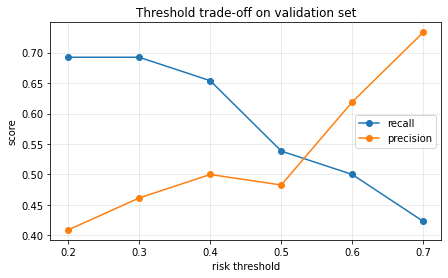

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(threshold_results['threshold'], threshold_results['recall'], marker='o', label='recall')
plt.plot(threshold_results['threshold'], threshold_results['precision'], marker='o', label='precision')
plt.xlabel('risk threshold')
plt.ylabel('score')
plt.title('Threshold trade-off on validation set')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 如何在本项目中选择阈值

如果学校能够承受更多人工跟进，且漏掉高风险学生的代价很高，可以选择较低阈值来提高 Recall。若干预资源非常有限，则需要更高 Precision，避免把大量资源投向误报学生。

本次验证集只有 79 名学生，结果会有波动。因此阈值选择应明确写为当前数据下的业务取舍，而不是宣称某个阈值永久最优。